<a href="https://colab.research.google.com/github/siojzz/Practical-Statistics-for-Data-Scientists/blob/main/PracticalStatisticsChapter2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 - Data and Sampling Distributions

This notebook contains my code reproduction and notes for Chapter 2 of *Practical Statistics for Data Scientists*.

This chapter focuses on sampling, sampling distributions, uncertainty, and several probability distributions used in data science.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.utils import resample

## 1. Random Sampling and Sample Bias

A sample is a subset taken from a larger population.

Random sampling gives each observation a chance to be selected. A good sample should represent the population as well as possible.

Sampling can be done with replacement or without replacement.

### 1.1 Sample Bias

Sample bias occurs when a sample does not properly represent the population.

A biased sample can produce misleading results even when the sample size is large.

## 2. Selection Bias

Selection bias happens when the process used to select data causes some observations to be more likely to appear in the sample than others.

This can make the results different from the real population.

## 3. Sampling Distribution of a Statistic

A sampling distribution is the distribution of a statistic calculated from many different samples.

For example, if we repeatedly take samples and calculate the mean, the collection of those means forms a sampling distribution.

In [2]:
!wget -O loans_income.csv https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loans_income.csv

--2026-10-01 06:42:05--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loans_income.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 308338 (301K) [text/plain]
Saving to: ‘loans_income.csv’

loans_income.csv    100%[===================>] 301.11K  --.-KB/s    in 0.08s   

2026-10-01 06:42:06 (3.72 MB/s) - ‘loans_income.csv’ saved [308338/308338]



In [3]:
loans_income = pd.read_csv("loans_income.csv").squeeze()

loans_income.head()

,x
0,67000
1,52000
2,100000
3,78762
4,37041


In [4]:
sample_data = pd.DataFrame({
    "income": loans_income.sample(1000),
    "type": "Data"
})

sample_mean_05 = pd.DataFrame({
    "income": [
        loans_income.sample(5).mean()
        for _ in range(1000)
    ],
    "type": "Mean of 5"
})

sample_mean_20 = pd.DataFrame({
    "income": [
        loans_income.sample(20).mean()
        for _ in range(1000)
    ],
    "type": "Mean of 20"
})

results = pd.concat([
    sample_data,
    sample_mean_05,
    sample_mean_20
])

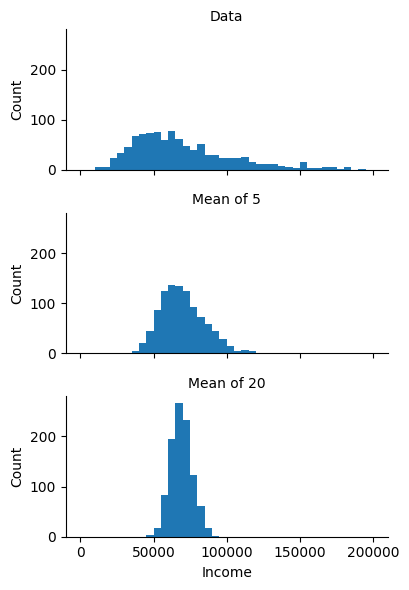

In [5]:
g = sns.FacetGrid(
    results,
    col="type",
    col_wrap=1,
    height=2,
    aspect=2
)

g.map(
    plt.hist,
    "income",
    range=[0, 200000],
    bins=40
)

g.set_axis_labels("Income", "Count")
g.set_titles("{col_name}")

plt.show()

**Interpretation:**

The distribution of individual income values is relatively wide and skewed.

The distribution of sample means becomes narrower and more bell-shaped as the sample size increases.

The means based on samples of 20 are more concentrated than the means based on samples of 5.

## 4. Central Limit Theorem

The Central Limit Theorem explains that the distribution of sample means tends to become approximately normal as the sample size becomes larger.

This can happen even when the original data is not normally distributed.

## 5. Standard Error

Standard error measures the variability of a sample statistic, such as the sample mean.

As the sample size increases, the standard error usually becomes smaller.

In [6]:
sample_size = 20

standard_error = (
    loans_income.std()
    / np.sqrt(sample_size)
)

standard_error

np.float64(7350.410564576207)

**Interpretation:**

The standard error represents how much a sample mean may vary between different samples.

A larger sample size usually produces a smaller standard error and a more stable estimate.

## 6. The Bootstrap

Bootstrap is a resampling method that repeatedly draws samples with replacement from the original data.

It is useful for estimating the variability of a statistic, such as the mean or median, without assuming a specific probability distribution.

In [7]:
results = []

for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())

results = pd.Series(results)

print("Bootstrap Statistics:")
print(f"original: {loans_income.median()}")
print(f"bias: {results.mean() - loans_income.median()}")
print(f"std. error: {results.std()}")

Bootstrap Statistics:
original: 62000.0
bias: -77.6140000000014
std. error: 230.00304760134236


**Interpretation:**

The original value is the median income from the observed dataset.

The bootstrap bias shows the difference between the average bootstrap estimate and the original median.

The bootstrap standard error shows how much the median may vary across repeated samples.

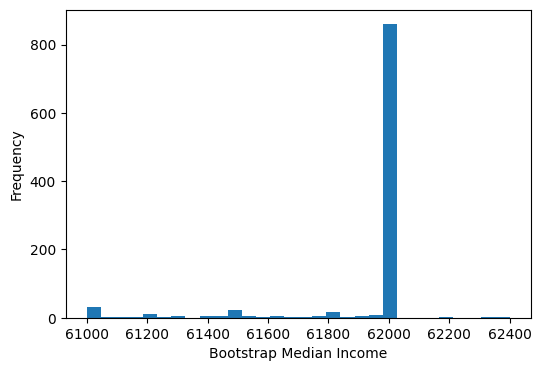

In [8]:
results.plot.hist(bins=30, figsize=(6, 4))

plt.xlabel("Bootstrap Median Income")
plt.ylabel("Frequency")
plt.show()

**Interpretation:**

The histogram shows the distribution of median income values obtained from repeated bootstrap samples.

The spread of the distribution represents the uncertainty of the estimated median.

## 7. Confidence Intervals

A confidence interval gives a range of values that represents the uncertainty around a sample estimate.

A confidence interval can be constructed using bootstrap results by taking the central part of the bootstrap distribution.

In [9]:
confidence_interval_90 = results.quantile([0.05, 0.95])

confidence_interval_90

,0
0.05,61288.625
0.95,62000.000


**Interpretation:**

The 90% confidence interval gives the central range of bootstrap median estimates.

It provides an idea of how much the estimated median income could vary due to sampling.

In [10]:
confidence_interval_95 = results.quantile([0.025, 0.975])

confidence_interval_95

,0
0.025,61000.0
0.975,62000.0


**Interpretation:**

The 95% confidence interval is wider than the 90% confidence interval because a higher confidence level requires a larger range.

## 8. Normal Distribution

The normal distribution is a bell-shaped distribution that is widely used in statistics.

It is especially useful because many sample statistics, such as sample means, tend to follow a normal distribution.

## 9. Standard Normal and QQ-Plots

A standard normal distribution has a mean of 0 and a standard deviation of 1.

A QQ-Plot is used to compare a dataset with a theoretical distribution, such as the normal distribution.

If the points follow the diagonal line closely, the data is approximately normally distributed.

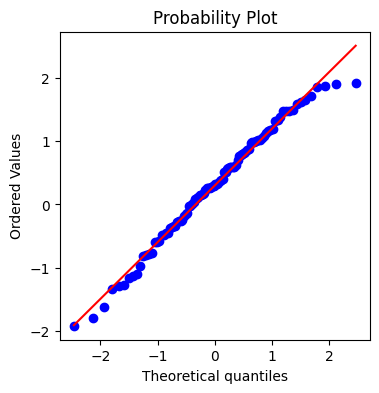

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))

norm_sample = stats.norm.rvs(size=100)

stats.probplot(norm_sample, plot=ax)

plt.show()

**Interpretation:**

Most points are close to the diagonal line.

This indicates that the generated sample is approximately normally distributed.

## 10. Long-Tailed Distributions

A long-tailed distribution has more extreme values than we would expect from a normal distribution.

Many real-world datasets are not normally distributed and may contain long tails or skewness.

In [12]:
!wget -O sp500_data.csv.gz https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_data.csv.gz

--2026-10-01 07:01:56--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_data.csv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21152050 (20M) [application/octet-stream]
Saving to: ‘sp500_data.csv.gz’

sp500_data.csv.gz   100%[===================>]  20.17M  72.1MB/s    in 0.3s    

2026-10-01 07:01:57 (72.1 MB/s) - ‘sp500_data.csv.gz’ saved [21152050/21152050]



In [13]:
sp500_px = pd.read_csv(
    "sp500_data.csv.gz",
    index_col=0
)

sp500_px.head()

,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,ALTR,...,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
1993-01-29,0.0,0.060124,-0.022100,0.0,0.0,0.018897,0.007368,0.092165,0.259140,-0.007105,...,0.0,0.0,0.34716,0.0,0.04167,0.00000,0.015564,1.75,0.1250,0.0
1993-02-01,0.0,-0.180389,0.027621,0.0,0.0,0.018889,0.018425,0.115207,-0.100775,0.063893,...,0.0,0.0,-0.23144,0.0,0.00000,-0.01041,0.007782,1.25,0.1250,0.0
1993-02-02,0.0,-0.120257,0.035900,0.0,0.0,-0.075573,0.029482,-0.023041,0.028796,-0.014192,...,0.0,0.0,-0.11572,0.0,0.00000,0.00000,-0.007792,-0.25,0.0000,0.0
1993-02-03,0.0,0.060124,-0.024857,0.0,0.0,-0.151128,0.003689,-0.253454,-0.043190,-0.007105,...,0.0,0.0,-0.08679,0.0,0.04167,-0.04167,-0.038919,-0.50,0.0625,0.0
1993-02-04,0.0,-0.360770,-0.060757,0.0,0.0,0.113350,-0.022114,0.069862,0.000000,-0.007096,...,0.0,0.0,0.14465,0.0,-0.04166,-0.03126,-0.046711,0.00,0.0625,0.0


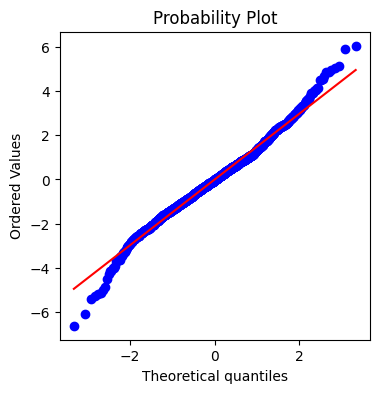

In [14]:
nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx > 0]))

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)

plt.show()

**Interpretation:**

The points deviate from the diagonal line, especially at the lower and upper ends.

This indicates that the Netflix returns have longer tails than a normal distribution and contain more extreme values.

## 11. Student's t-Distribution

The t-distribution is similar to the normal distribution but has thicker tails.

It is commonly used for sample statistics when the sample size is relatively small.

As the sample size becomes larger, the t-distribution becomes more similar to the normal distribution.

## 12. Binomial Distribution

The binomial distribution is used when an experiment has two possible outcomes, such as success or failure.

It describes the number of successes in a fixed number of trials when each trial has the same probability of success.

In [15]:
stats.binom.pmf(2, n=5, p=0.1)

np.float64(0.07289999999999992)

In [16]:
stats.binom.cdf(2, n=5, p=0.1)

np.float64(0.99144)

**Interpretation:**

The PMF gives the probability of getting exactly 2 successes in 5 trials.

The CDF gives the probability of getting 2 or fewer successes in 5 trials.

## 13. Chi-Square Distribution

The chi-square distribution is commonly used with categorical count data.

The chi-square statistic measures how much the observed values differ from the values expected under a null model.

A larger chi-square value means a larger difference between observed and expected values.

## 14. F-Distribution

The F-distribution is commonly used when comparing variability between groups.

The F-statistic compares variation between group means with variation within the groups.

It is commonly used in ANOVA and regression analysis.

## 15. Poisson and Related Distributions

### 15.1 Poisson Distribution

The Poisson distribution models the number of events that occur in a fixed interval of time or space.

The main parameter is lambda, which represents the average number of events in the interval.

In [17]:
poisson_sample = stats.poisson.rvs(2, size=100)

poisson_sample[:10]

array([5, 2, 4, 0, 5, 1, 0, 5, 2, 5])

**Interpretation:**

The code simulates 100 intervals where the average event rate is 2 events per interval.

### 15.2 Exponential Distribution

The exponential distribution models the time or distance between events.

It is useful when events occur randomly at a constant rate.

In [18]:
exponential_sample = stats.expon.rvs(0.2, size=100)

exponential_sample[:10]

array([0.25769072, 0.4862721 , 1.07668694, 0.39135798, 1.55334415,
       1.40102143, 0.75726848, 0.45219015, 0.74901883, 1.48584091])

**Interpretation:**

The generated values represent simulated intervals between events based on the specified rate parameter.

### 15.3 Weibull Distribution

The Weibull distribution is commonly used for time-to-failure analysis.

Unlike the exponential distribution, the event rate can change over time depending on its shape parameter.

In [19]:
weibull_sample = stats.weibull_min.rvs(
    1.5,
    scale=5000,
    size=100
)

weibull_sample[:10]

array([12071.26333739,  1133.93405357,  3762.58123422,  5115.86471998,
        2875.21930238,   622.85667945,  9907.91586753,  4508.34985597,
        5404.96650674,   598.56528899])

## 16. Chapter Summary

In this chapter, I learned how sampling and probability distributions are used to understand uncertainty in data.

The main topics covered were:

- Random sampling and sample bias
- Selection bias
- Sampling distributions
- Central Limit Theorem
- Standard error
- Bootstrap
- Confidence intervals
- Normal and standard normal distributions
- QQ-Plots
- Long-tailed distributions
- Student's t-distribution
- Binomial distribution
- Chi-square distribution
- F-distribution
- Poisson distribution
- Exponential distribution
- Weibull distribution

These concepts help explain how sample results can vary and how probability distributions can be used to model different types of data and events.